## Generate a dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
%matplotlib inline

np.random.seed(42)

# Genera train data
X = 0.3 * np.random.randn(100, 2)
# Genera algunas observaciones
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X + 2, X - 2, X_outliers]


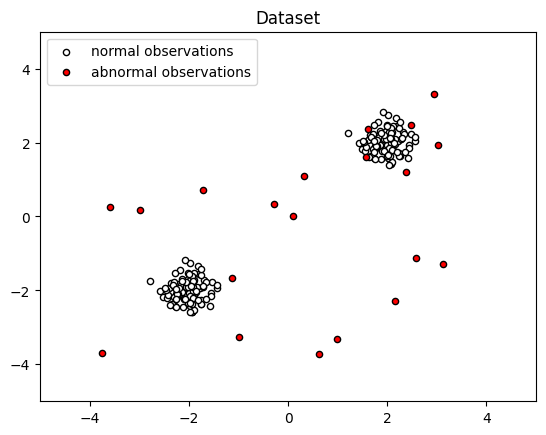

In [2]:
a = plt.scatter(X[:200, 0], X[:200, 1], c='white',
                edgecolor='k', s=20)
b = plt.scatter(X[200:, 0], X[200:, 1], c='red',
                edgecolor='k', s=20)

plt.axis('tight')
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.legend([a, b],
           ["normal observations",
            "abnormal observations"],
           loc="upper left")

plt.title("Dataset")

plt.show()


## Automatic multivariate tools

In [6]:
from sklearn.neighbors import LocalOutlierFactor

# fit the model
clf = LocalOutlierFactor(n_neighbors=20, novelty=True)
clf.fit(X)
y_pred = clf.predict(X)
y_pred_outliers = y_pred[200:]

![LOF](https://scikit-learn.org/stable/_images/sphx_glr_plot_lof_outlier_detection_001.png)

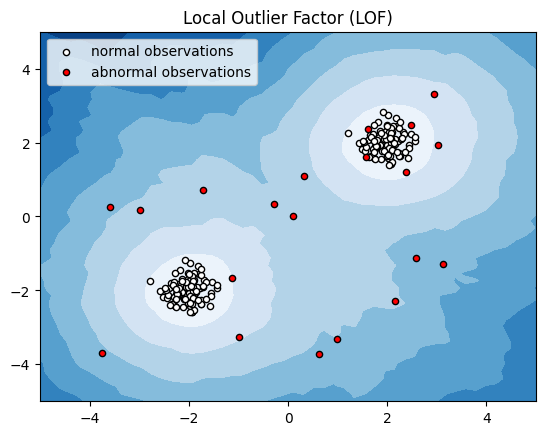

In [7]:
# plot the level sets of the decision function
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
Z = clf.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

a = plt.scatter(X[:200, 0], X[:200, 1], c='white',
                edgecolor='k', s=20)
b = plt.scatter(X[200:, 0], X[200:, 1], c='red',
                edgecolor='k', s=20)
plt.axis('tight')
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.legend([a, b],
           ["normal observations",
            "abnormal observations"],
           loc="upper left")

plt.title("Local Outlier Factor (LOF)")

plt.show()

In [8]:
# fit the model
clf = IsolationForest(max_samples=100)
clf.fit(X)
y_pred_forest = clf.predict(X)

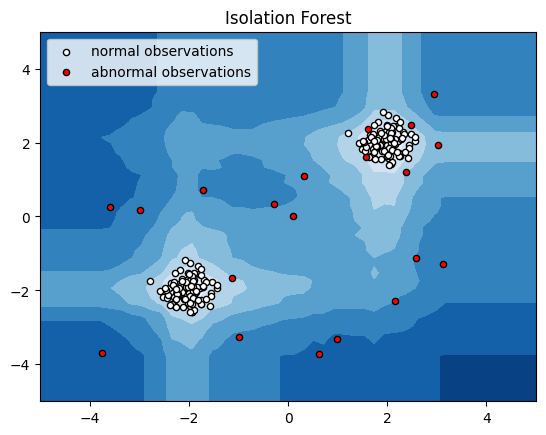

In [9]:
plt.title("Isolation Forest")

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

a = plt.scatter(X[:200, 0], X[:200, 1], c='white',
                edgecolor='k', s=20)
b = plt.scatter(X[200:, 0], X[200:, 1], c='red',
                edgecolor='k', s=20)

plt.axis('tight')
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.legend([a, b],
           ["normal observations",
            "abnormal observations"],
           loc="upper left")
plt.show()

![outliers methods](https://scikit-learn.org/0.20/_images/sphx_glr_plot_anomaly_comparison_001.png)

## Direct exploration

In [10]:

sns.__version__

NameError: name 'sns' is not defined

In [12]:
#OUTLIER DETECTION
from sklearn.datasets import fetch_california_housing
import pandas as pd

#DETECTAR Y REMOVER Outliers
housing = fetch_california_housing()

housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [14]:
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [15]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [16]:

'''
Load and return the boston house-prices dataset (regression).
Samples total 	506
Dimensionality 	13
Features 	real, positive
Targets 	real 5. - 50.
'''

#create the dataframe
housing_df = pd.DataFrame(housing.data)

housing_df.columns = housing.feature_names

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [18]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


<Axes: >

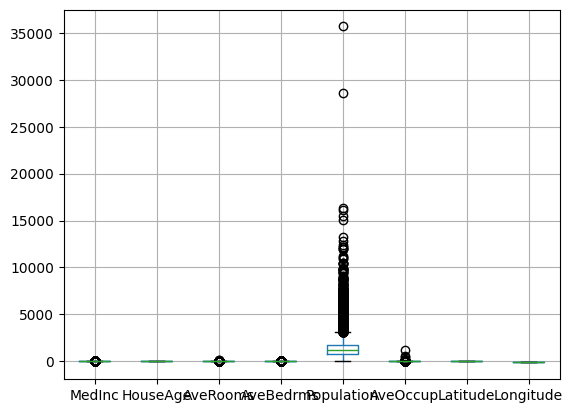

In [19]:
%matplotlib inline
housing_df.boxplot()

<Axes: xlabel='MedInc'>

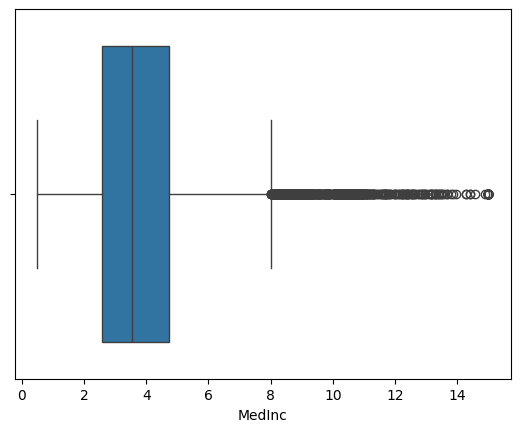

In [22]:
%matplotlib inline
import seaborn as sns

sns.boxplot(x=housing_df['MedInc'])


array([[<Axes: title={'center': 'MedInc'}>]], dtype=object)

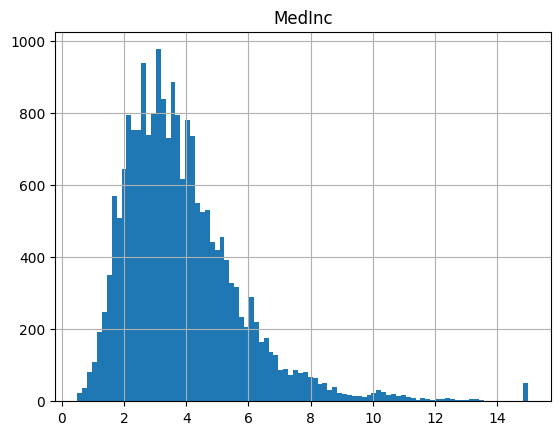

In [24]:
housing_df.hist(column="MedInc", bins='auto')

array([[<Axes: title={'center': 'Data'}>]], dtype=object)

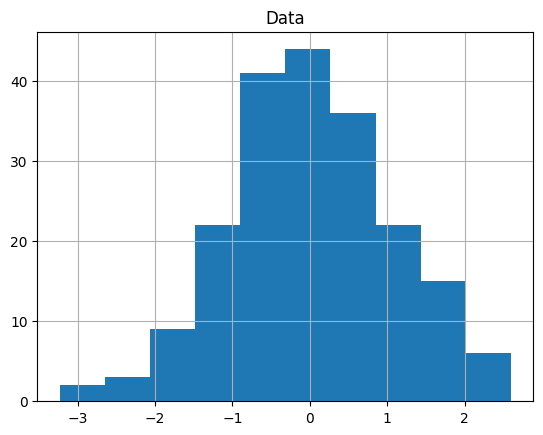

In [25]:
# HERE WE CREATE A randomly generated dataset of normally distributed data 1-column.
import numpy as np
np.random.seed(123) #you can fix the random seed for reproducibility
df = pd.DataFrame({'Data':np.random.normal(size=200)})
df.hist(column="Data")

In [26]:
df

,Data
0,-1.085631
1,0.997345
2,0.282978
3,-1.506295
4,-0.578600
...,...
195,-3.231055
196,-0.269293
197,-0.110851
198,-0.341262


<Axes: xlabel='Data'>

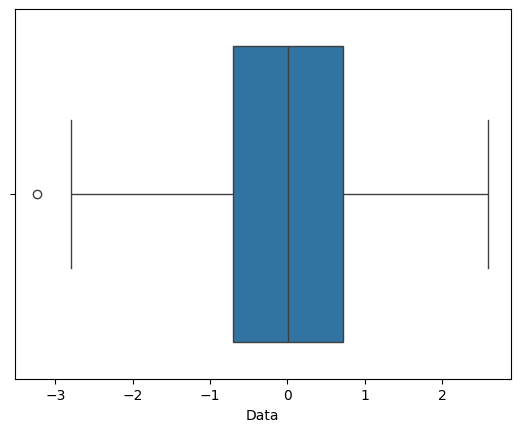

In [27]:
sns.boxplot(x=df.Data)

In [28]:
#since it is normal then I CAN REMOVE OUTLIERS Using Normal Distribution and S.D
mean = df.mean()
sd = df.std()

# keep only the ones that are within +x to -x standard deviations in the column DIS
x = 3
df = df[ np.abs(df - mean) <= 3 * sd ]

array([[<Axes: title={'center': 'Data'}>]], dtype=object)

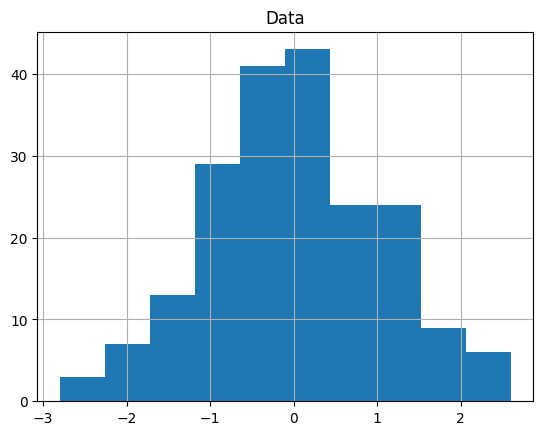

In [29]:
df.hist(column="Data")

<Axes: xlabel='Data'>

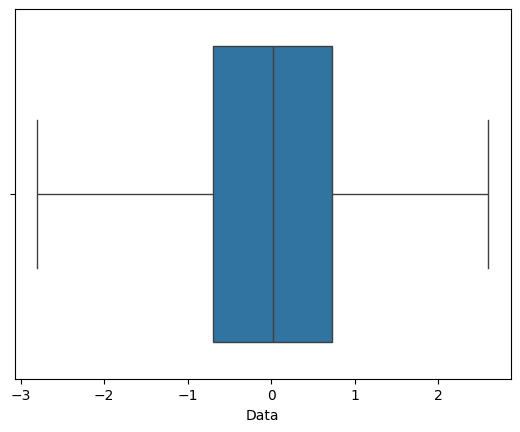

In [30]:
sns.boxplot(x=df.Data)

<Axes: xlabel='AveRooms'>

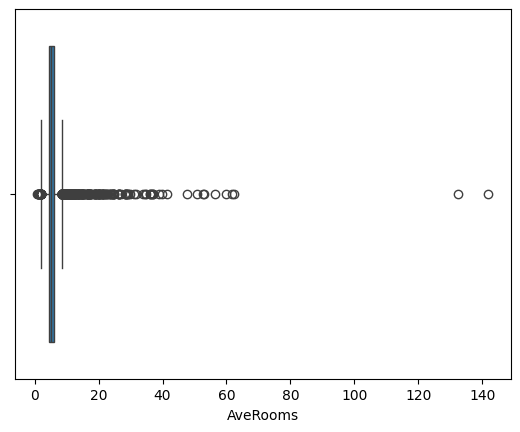

In [33]:
## check your data first
df2=pd.DataFrame(housing_df["AveRooms"])
mean2 = df2.mean()
sd2 = df2.std()

df2.describe()
sns.boxplot(x=housing_df.AveRooms)

#df2.shape

array([[<Axes: title={'center': 'AveRooms'}>]], dtype=object)

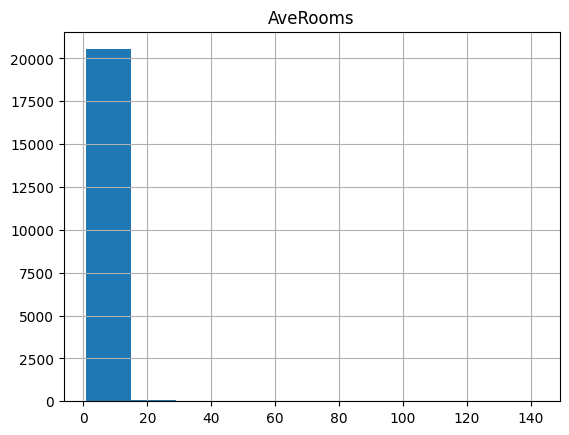

In [34]:
df2.hist()


array([[<Axes: title={'center': 'AveRooms'}>]], dtype=object)

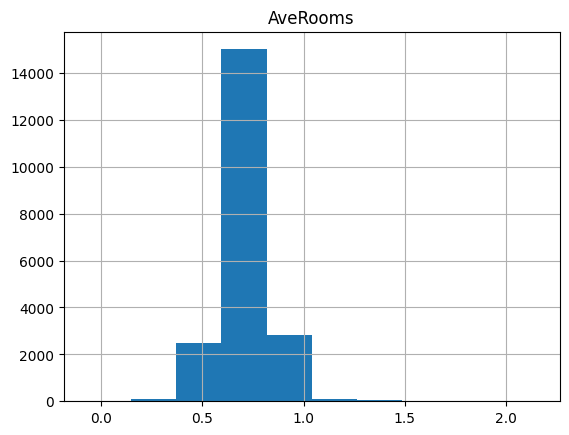

In [35]:
#df2.hist()
import numpy as np
np.log10(df2).hist()


<Axes: xlabel='AveRooms'>

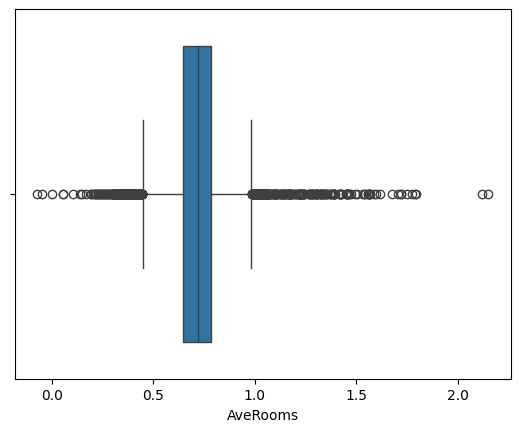

In [37]:
import numpy as np

import seaborn as sns

sns.boxplot(x=np.log10(housing_df.AveRooms))

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3